<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Following_of_Time_Series_Forecasting_with_new_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

For this second step of the project I have copied the original notebook and chose ["Electric Power Consumption Dataset: Introduction"](https://www.kaggle.com/code/fedesoriano/electric-power-consumption-dataset-introduction) as the new dataset. The goal of the usage of this new dataset is to make models that can accurately predict usage of electricity in zone1. Any addition to methods or models will be noted otherwise everything is the same as original.

###**Imports**

In [ ]:
import os
import datetime
import kagglehub
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from zipfile import ZipFile

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

Import path and set df

In [ ]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")

print("Path to dataset files:", path)
df=pd.read_csv(os.path.join(path,'powerconsumption.csv'))
date_time = df.pop('Datetime')


Using Colab cache for faster access to the 'electric-power-consumption' dataset.
Path to dataset files: /kaggle/input/electric-power-consumption


Show top 5

In [ ]:
df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
print(df.describe())
print(df.info())

        Temperature      Humidity     WindSpeed  GeneralDiffuseFlows  \
count  52416.000000  52416.000000  52416.000000         52416.000000   
mean      18.810024     68.259518      1.959489           182.696614   
std        5.815476     15.551177      2.348862           264.400960   
min        3.247000     11.340000      0.050000             0.004000   
25%       14.410000     58.310000      0.078000             0.062000   
50%       18.780000     69.860000      0.086000             5.035500   
75%       22.890000     81.400000      4.915000           319.600000   
max       40.010000     94.800000      6.483000          1163.000000   

       DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
count  52416.000000            52416.000000            52416.000000   
mean      75.028022            32344.970564            21042.509082   
std      124.210949             7130.562564             5201.465892   
min        0.011000            13895.696200             8560.081466

I am lucky enough to not have any NANs or null here. However to note for Temperature and windspeed I am not given a metric. This won't impact largely the calculations. I will not need to convert any circuler data such as windspeed as well because it doesn't seem to be in degrees as seen in .describe(). There will be no need to change date as well it is already in datetime. It is interesting how the median values and below of windspeed is so small compared to above.

Show the change of Temperature, WindSpeed, and Humadity over time

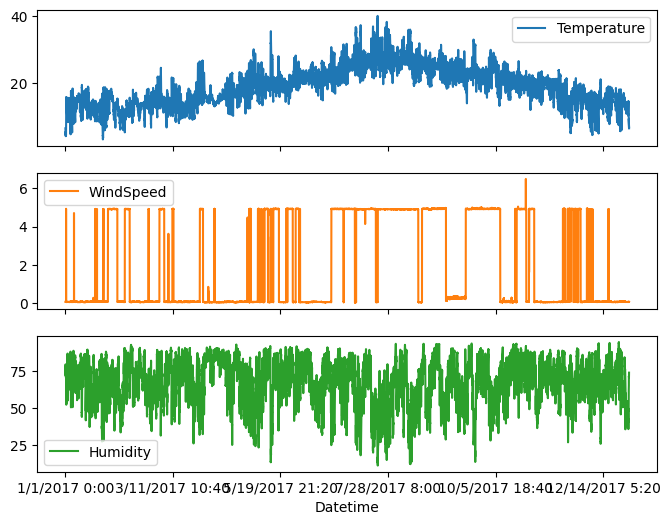

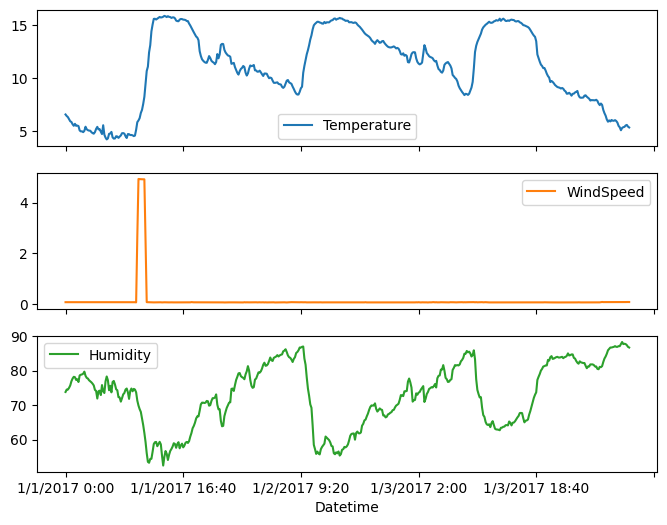

In [ ]:
plot_cols = ['Temperature', 'WindSpeed', 'Humidity']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

Split the data but no shuffling to maintain some order as this is time series data these patterns hold information

In [ ]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

data normilization through simple averages interesting to think about how only training data is used for this and how moving averages could be more honest.

So I am trying rolling averages and seeing the changes and challenges it makes

In [ ]:
train_df_roll = train_df.copy()
val_df_roll = val_df.copy()
test_df_roll = test_df.copy()

/tmp/ipykernel_17150/3281136885.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


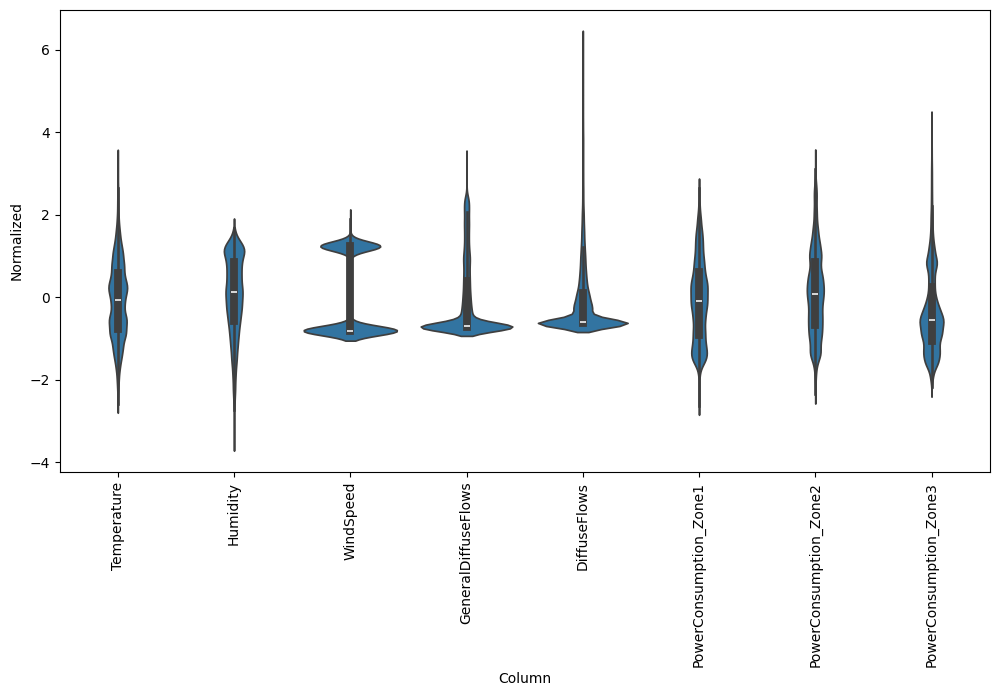

In [ ]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

df_std = (df - train_mean) / train_std

df_std = df_std.melt(
    var_name='Column',
    value_name='Normalized'
)

plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    x='Column',
    y='Normalized',
    data=df_std
)

_ = ax.set_xticklabels(df.keys(), rotation=90)

With rolling averages everything is compressed, centralized to 0, and windspeed has a massive spike. This destoys the integrity of future models and no predictions were possible. So for my use case I will stick with globabl instead of rolling.

/tmp/ipykernel_17150/3903188381.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


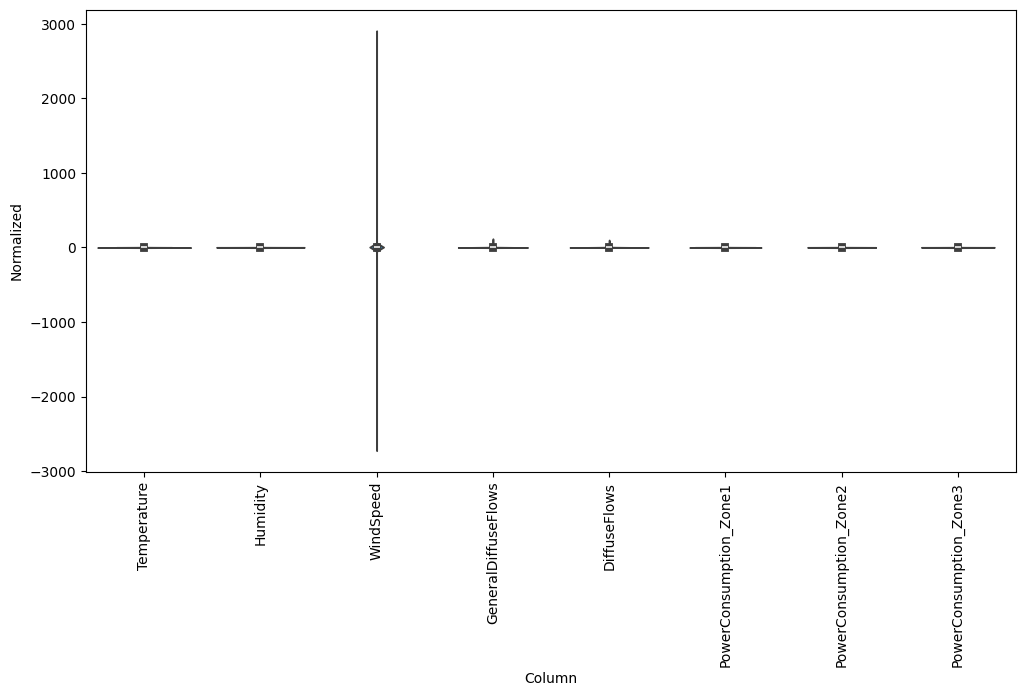

In [ ]:
window = 24

rolling_mean_roll = (
    train_df_roll
    .rolling(window=window, min_periods=1)
    .mean()
    .shift(1)
)

rolling_std_roll = (
    train_df_roll
    .rolling(window=window, min_periods=1)
    .std()
    .shift(1)
)

train_df_roll = (
    (train_df_roll - rolling_mean_roll)
    / rolling_std_roll
)

train_df_roll = train_df_roll.dropna()

val_df_roll = (
    (val_df_roll - rolling_mean_roll)
    / rolling_std_roll
)

test_df_roll = (
    (test_df_roll - rolling_mean_roll)
    / rolling_std_roll
)

df_std_roll = (
    (df - rolling_mean_roll)
    / rolling_std_roll
)

df_std_roll = df_std_roll.melt(
    var_name='Column',
    value_name='Normalized'
)

plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    x='Column',
    y='Normalized',
    data=df_std_roll
)

_ = ax.set_xticklabels(df.keys(), rotation=90)

data windowing here is implemented with hours and you can set the input of hours and how far you want to predict with what features

In [ ]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

making 2 windows with window size, input, labels, and label columns

In [ ]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['PowerConsumption_Zone1'])
print(w1)

w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['PowerConsumption_Zone1'])
print(w2)

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['PowerConsumption_Zone1']
Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['PowerConsumption_Zone1']


Split into two windows of one label to be predicted and the input information

In [ ]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

Test of split

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 8)
Inputs shape: (3, 6, 8)
Labels shape: (3, 1, 1)


visualization of the split windows

In [ ]:
w2.example = example_inputs, example_labels

def plot(self, model=None, plot_col='PowerConsumption_Zone1', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

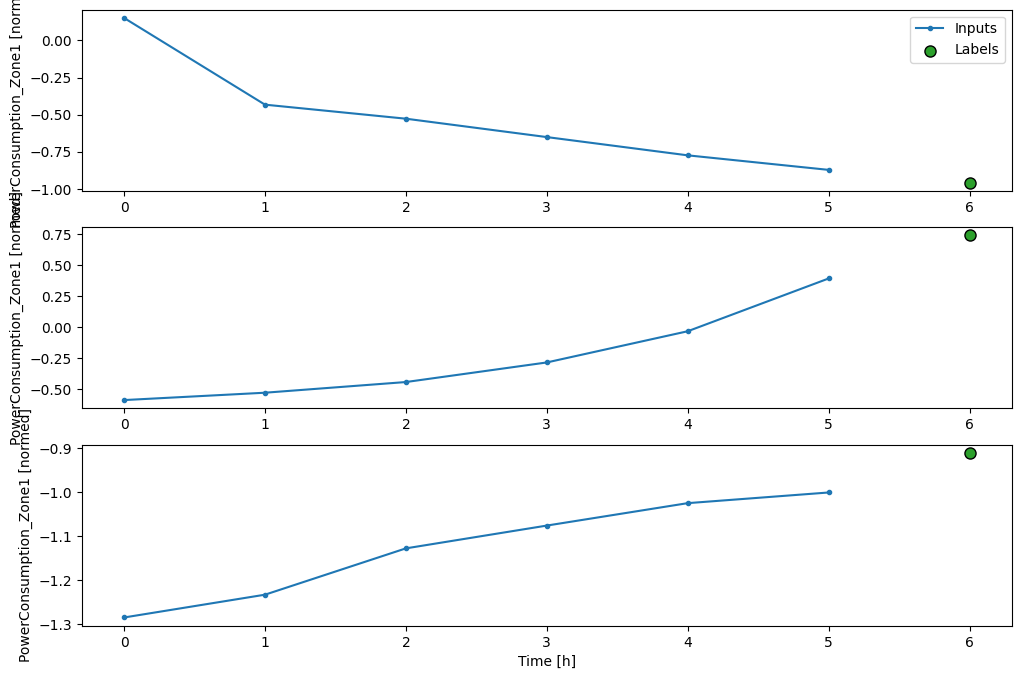

In [ ]:
w2.plot()

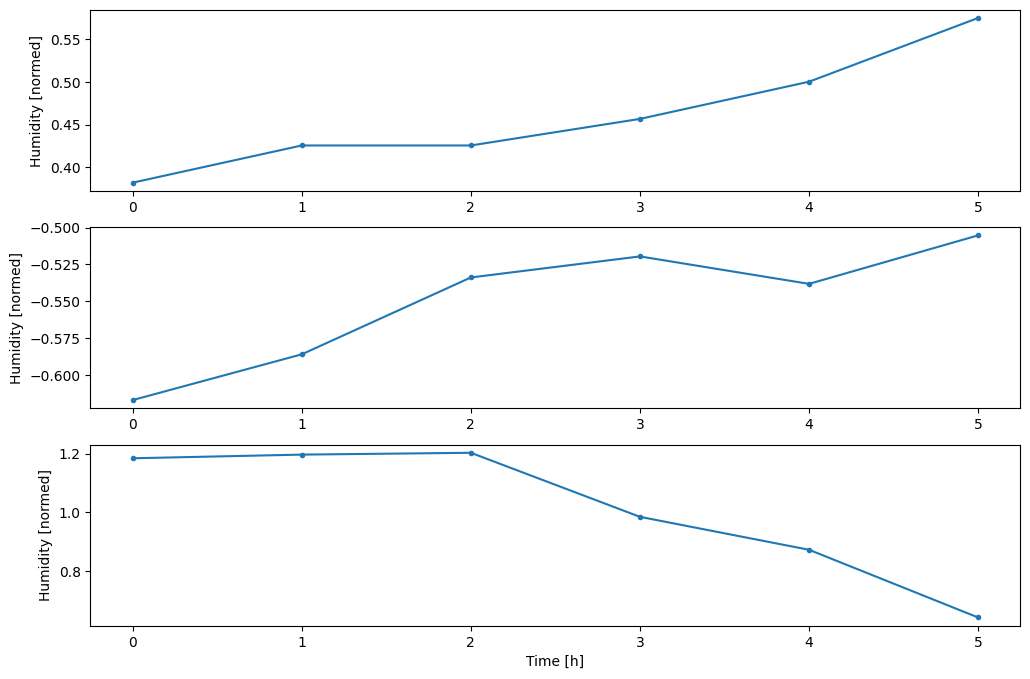

In [ ]:
w2.plot(plot_col='Humidity')

turning dataframe into tf dataset which is better for model ingestion and batching

In [ ]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

accessor funcs

In [ ]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

Show dataset specifications

In [ ]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 8), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

show the batches created by the dataset

In [ ]:
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 8)
Labels shape (batch, time, features): (32, 1, 1)


Making a model that predicts one hour on a single feature

In [ ]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['PowerConsumption_Zone1'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['PowerConsumption_Zone1']

iterate the model over the batches

In [ ]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 8)
Labels shape (batch, time, features): (32, 1, 1)


Starting with predicting no chnage as a baseline performance of the single output model

In [ ]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [ ]:
baseline = Baseline(label_index=column_indices['PowerConsumption_Zone1'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0068 - mean_absolute_error: 0.0549


Each batch through time is indepedent from each other. so no interaction from the previous to impact the current prediction being made

In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['PowerConsumption_Zone1'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['PowerConsumption_Zone1']

show the shape and the plot

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 8)
Output shape: (32, 24, 1)


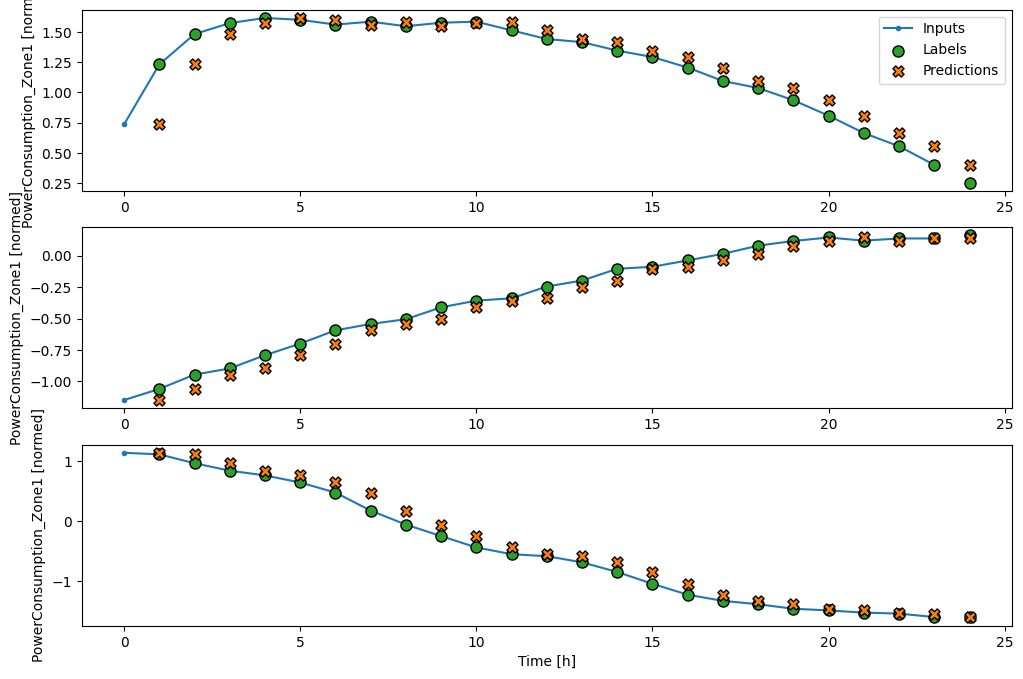

In [ ]:
wide_window.plot(baseline)

Making and training linear model with no transformation for activation making it just linear transformations

In [ ]:
linear = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1)
])

print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

Input shape: (32, 1, 8)
Output shape: (32, 1, 1)


In [ ]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

Eval

In [ ]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2243 - mean_absolute_error: 0.3311 - val_loss: 0.1271 - val_mean_absolute_error: 0.3162
Epoch 2/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0141 - mean_absolute_error: 0.0876 - val_loss: 0.0080 - val_mean_absolute_error: 0.0603
Epoch 3/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0078 - mean_absolute_error: 0.0595 - val_loss: 0.0070 - val_mean_absolute_error: 0.0590
Epoch 4/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0077 - mean_absolute_error: 0.0587 - val_loss: 0.0070 - val_mean_absolute_error: 0.0591
Epoch 5/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0077 - mean_absolute_error: 0.0588 - val_loss: 0.0070 - val_mean_absolute_error: 0.0597
Epoch 6/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0077 - mean_absolute_error: 0.0589 - val_loss: 0.0070 - val_mean_absolute_error: 0.0598
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0070 - mean_absolute_error: 0.059

wide window visualizations

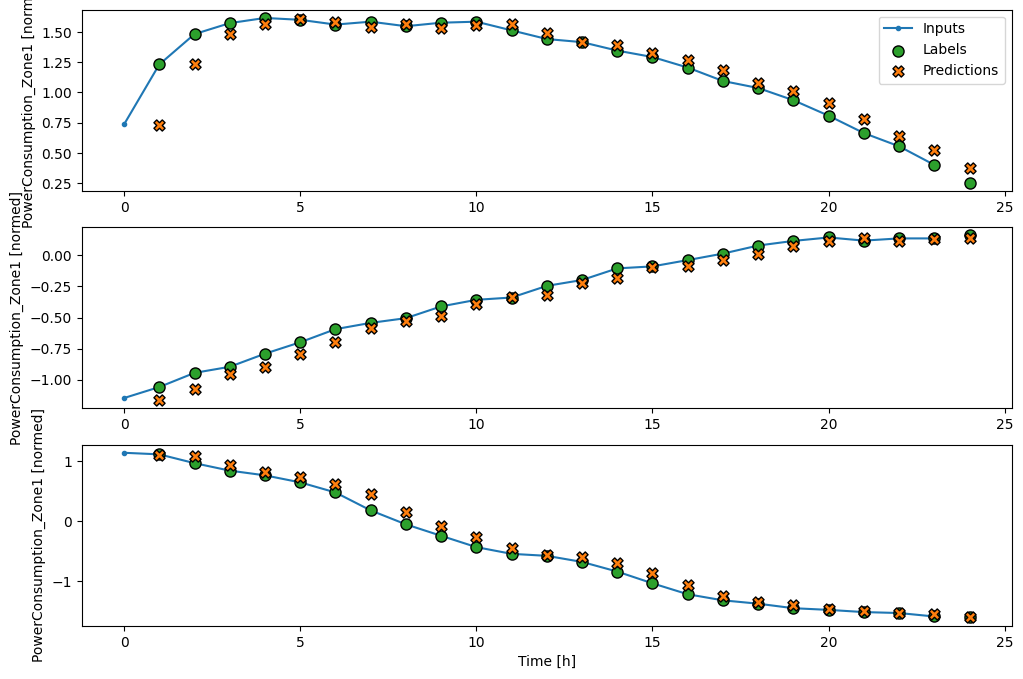

In [ ]:
wide_window.plot(linear)

showing the weights of each layers weight
Random initialization could run the risk of not having a weight on certain features

It is to be noted in the original of course temperature would be the best feature to predict the future temperature. But there were still other spikes of different features showing high or very low importance in that data.

This data shows zone1 itself is the best predictor for the next hours usage compared to anything else. This also shows every other zone's usage could be independant due to the lack of importance and humadity's weight is 0.

No feature is negative however unlike the original dataset.

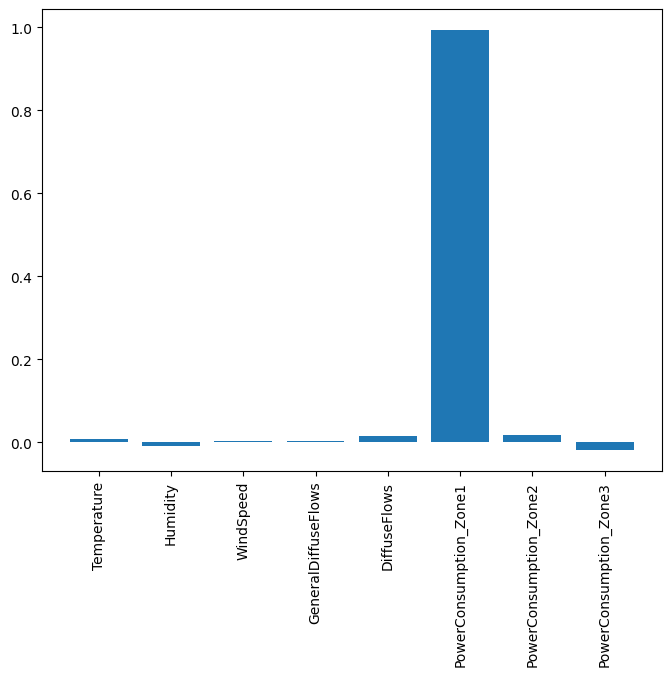

In [ ]:
plt.bar(x = range(len(train_df.columns)),
        height=linear.layers[0].kernel[:,0].numpy())
axis = plt.gca()
axis.set_xticks(range(len(train_df.columns)))
_ = axis.set_xticklabels(train_df.columns, rotation=90)

Multi-layer version

In [ ]:
dense = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0239 - mean_absolute_error: 0.0810 - val_loss: 0.0111 - val_mean_absolute_error: 0.0746
Epoch 2/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0058 - mean_absolute_error: 0.0527 - val_loss: 0.0104 - val_mean_absolute_error: 0.0722
Epoch 3/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0054 - mean_absolute_error: 0.0505 - val_loss: 0.0083 - val_mean_absolute_error: 0.0625
Epoch 4/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0052 - mean_absolute_error: 0.0497 - val_loss: 0.0087 - val_mean_absolute_error: 0.0645
Epoch 5/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0049 - mean_absolute_error: 0.0482 - val_loss: 0.0092 - val_mean_absolute_error: 0.0697
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0092 - mean_absolute_error: 0.0697


Creating new window and plotting it

In [ ]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['PowerConsumption_Zone1'])

conv_window

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['PowerConsumption_Zone1']

Text(0.5, 0.98, 'Given 3 hours of inputs, predict 1 hour into the future.')

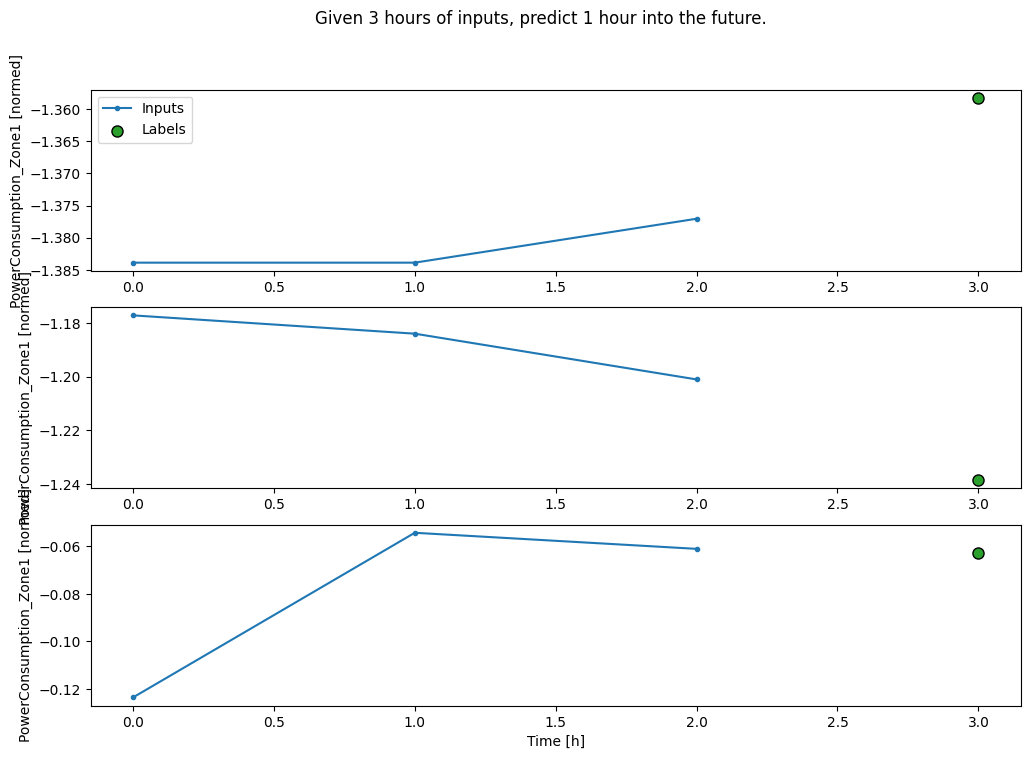

In [ ]:
conv_window.plot()
plt.suptitle("Given 3 hours of inputs, predict 1 hour into the future.")

Train, fit, and plot model

In [ ]:
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

In [ ]:
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

Input shape: (32, 3, 8)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(multi_step_dense, conv_window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0034 - mean_absolute_error: 0.0435


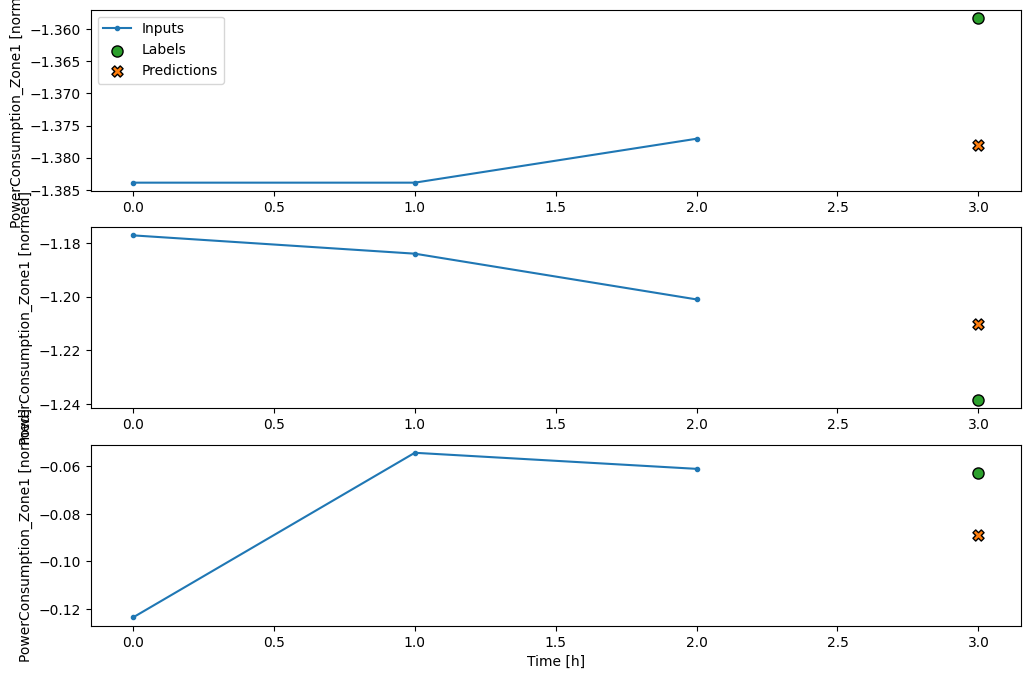

In [ ]:
conv_window.plot(multi_step_dense)

Set up CNN and show outputs to compare with multilayer

In [ ]:
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [ ]:
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

Conv model on `conv_window`
Input shape: (32, 3, 8)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(conv_model, conv_window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - mean_absolute_error: 0.0537


Showing how CNN can use different shapes

In [ ]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 8)
Labels shape: (32, 24, 1)
Output shape: (32, 22, 1)


There is now a need to balance the output and input. This would need to be fixed for training or plotting

In [ ]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['PowerConsumption_Zone1'])

wide_conv_window

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['PowerConsumption_Zone1']

Show changes

In [ ]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Wide conv window
Input shape: (32, 26, 8)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


Plot this new model

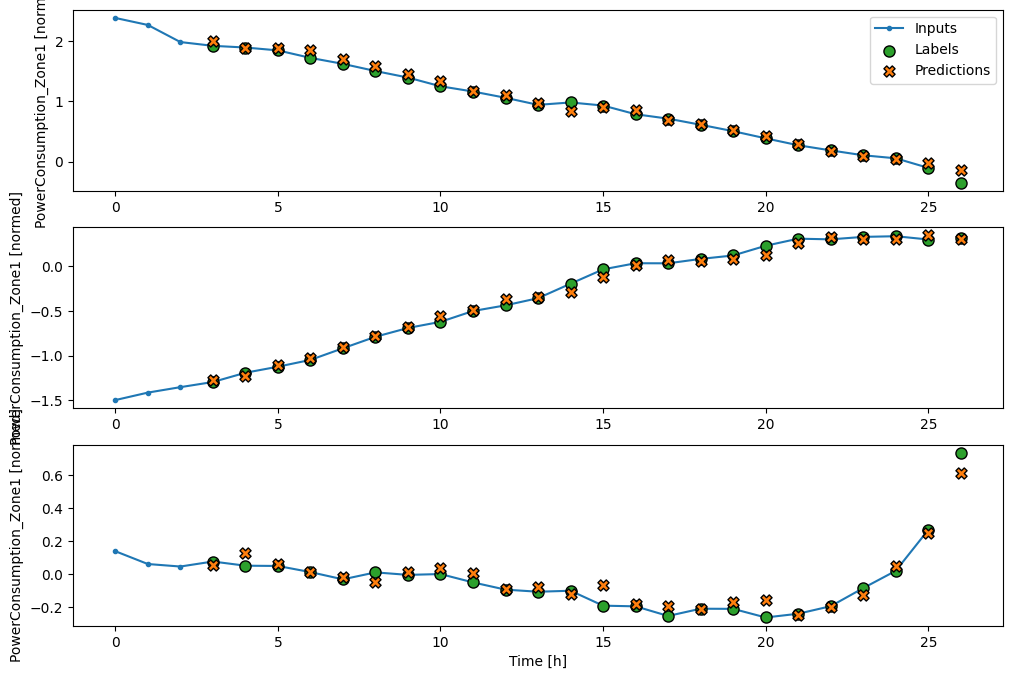

In [ ]:
wide_conv_window.plot(conv_model)

Now testing performance with an RNN model. It uses an internal state to move through a series of internal outputs to give one final output steo by step. You can also have a version with multiple steps being done and visible which is good for stacking RNN layers or training multiple steps at once.

Creating model

In [ ]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

RNN is good because of this sequential ability but not good for large scale/long sequences because of memory and the gradients decaying as backpropagation extends.

Shape

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 8)
Output shape: (32, 24, 1)


fitting and plotting

327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0034 - mean_absolute_error: 0.0414


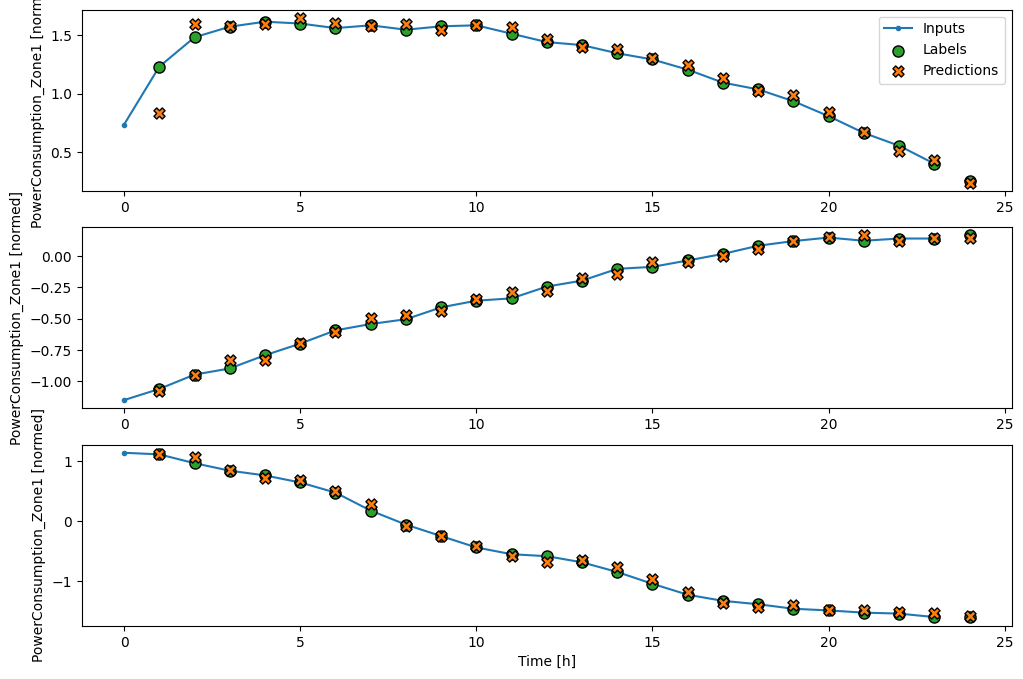

In [ ]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

wide_window.plot(lstm_model)

Performance views

In [ ]:
cm = lstm_model.metrics[1]
cm.metrics

[<MeanAbsoluteError name=mean_absolute_error>]

In [ ]:
val_performance

{'Baseline': {'loss': 0.006769619416445494,
  'mean_absolute_error': 0.05492599681019783},
 'Linear': {'loss': 0.007021140772849321,
  'mean_absolute_error': 0.05976780131459236},
 'Dense': {'loss': 0.009184138849377632,
  'mean_absolute_error': 0.06971225887537003},
 'Multi step dense': {'loss': 0.0034101027995347977,
  'mean_absolute_error': 0.04345861077308655},
 'Conv': {'loss': 0.0049038478173315525,
  'mean_absolute_error': 0.053737103939056396},
 'LSTM': {'loss': 0.0033637010492384434,
  'mean_absolute_error': 0.041443344205617905}}

Plotting performance of validation vs test

It is intersting here unlike the original, the MAE is higher in the test set than the validation set. The baseline and multistep dense performed the best. In some models the test was better than the validation but like dense and conv performed the worst comapered the rest but still well.

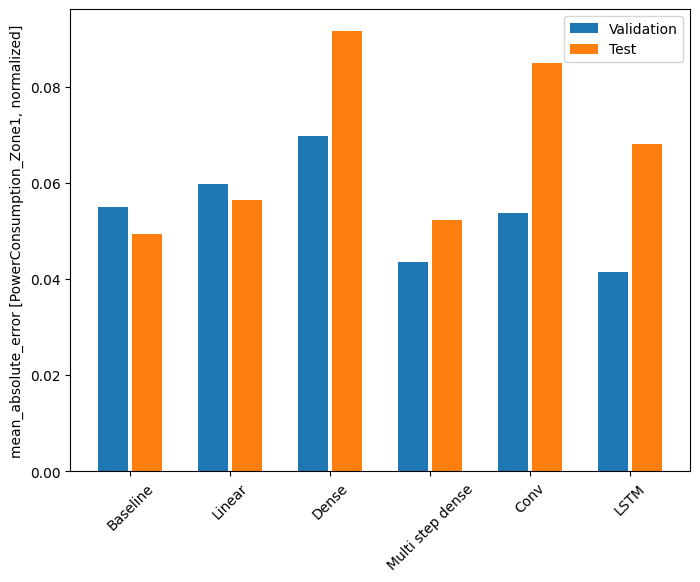

In [ ]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.ylabel('mean_absolute_error [PowerConsumption_Zone1, normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()

General performance of all models

In general this is a pretty good performance with low error.

In [ ]:
for name, value in performance.items():
  print(f'{name:12s}: {value[metric_name]:0.4f}')

Baseline    : 0.0494
Linear      : 0.0564
Dense       : 0.0915
Multi step dense: 0.0522
Conv        : 0.0849
LSTM        : 0.0682


Now the tutorial moves on to multistep prediction models with a singleshot method

Setup window

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): None

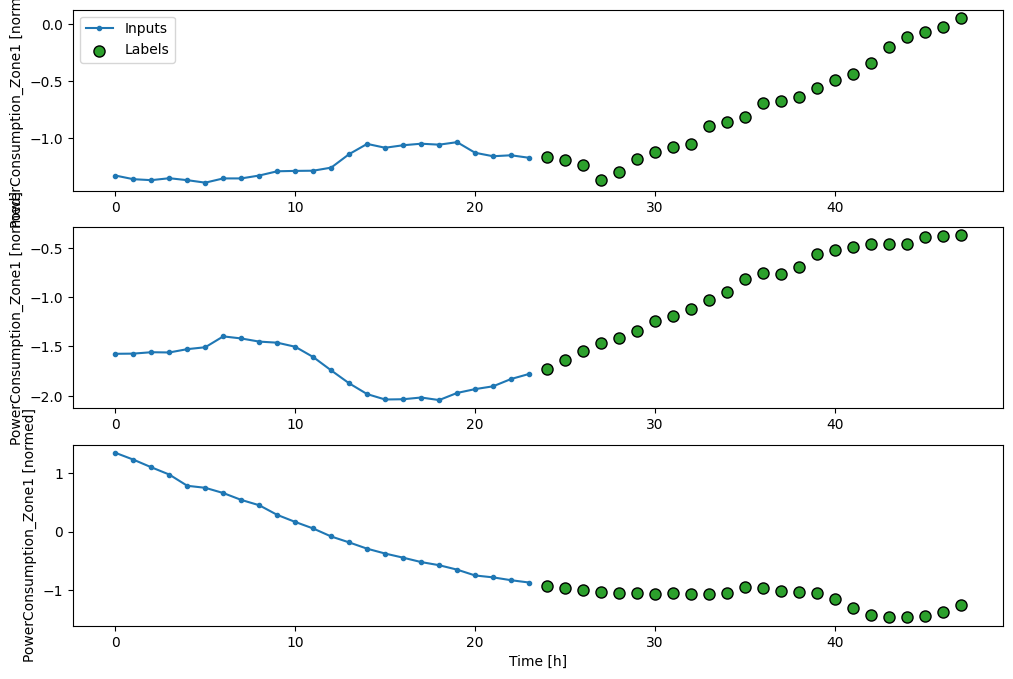

In [ ]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS)

multi_window.plot()
multi_window

Slight change on baseline to have multiple predictions then plot

327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2903 - mean_absolute_error: 0.3114


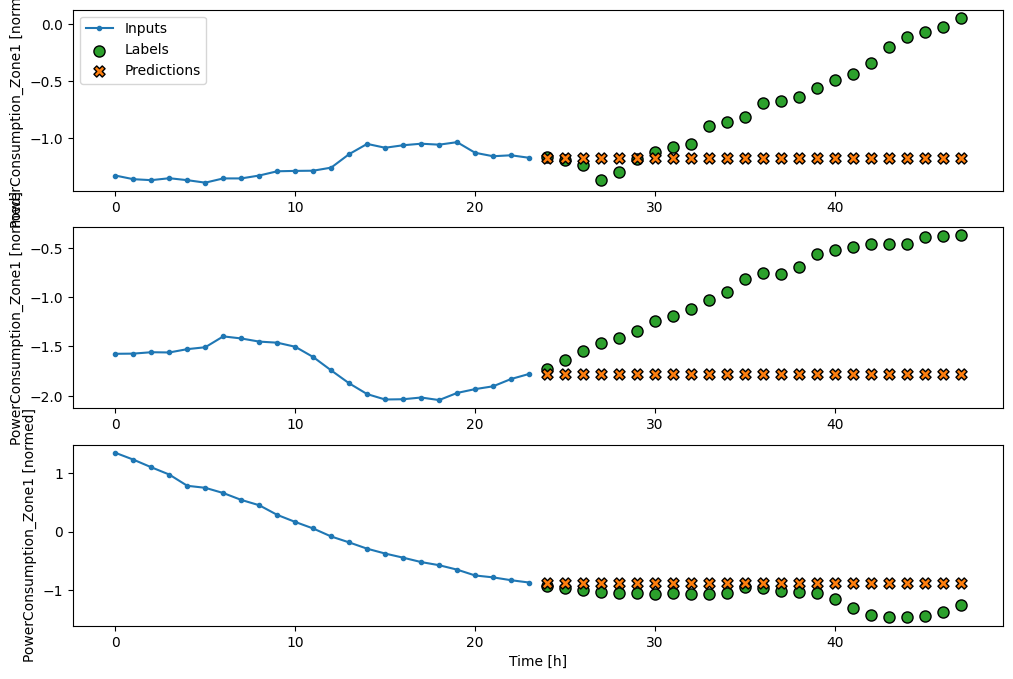

In [ ]:
class MultiStepLastBaseline(tf.keras.Model):
  def call(self, inputs):
    return tf.tile(inputs[:, -1:, :], [1, OUT_STEPS, 1])

last_baseline = MultiStepLastBaseline()
last_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                      metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance = {}
multi_performance = {}

multi_val_performance['Last'] = last_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Last'] = last_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(last_baseline)

Now with lack of change on days assumption

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6306 - mean_absolute_error: 0.5313


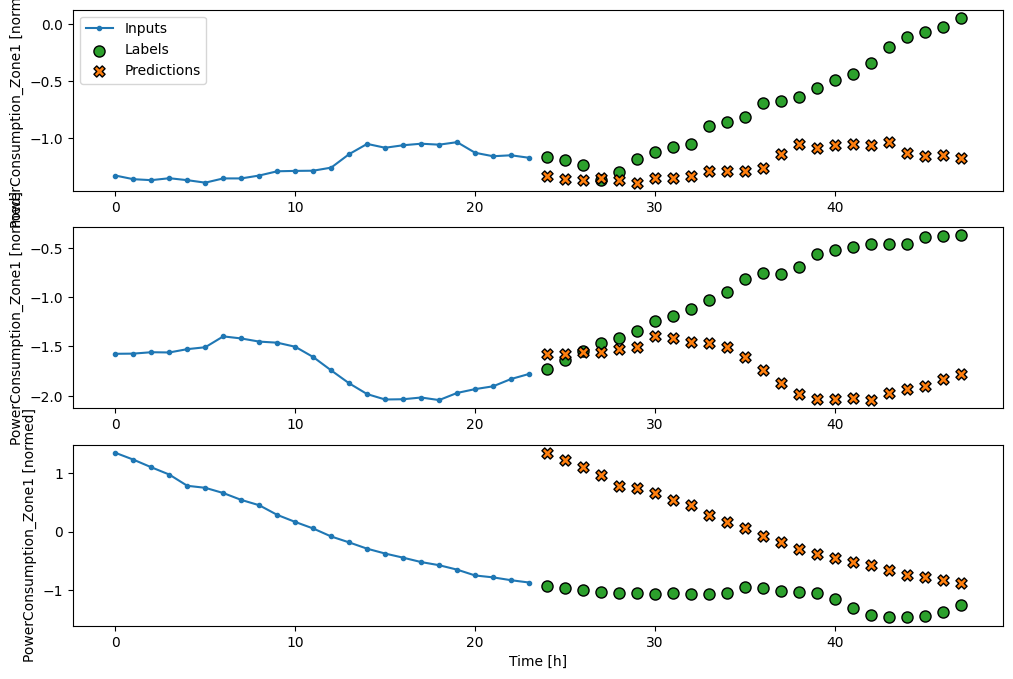

In [ ]:
class RepeatBaseline(tf.keras.Model):
  def call(self, inputs):
    return inputs

repeat_baseline = RepeatBaseline()
repeat_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                        metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance['Repeat'] = repeat_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Repeat'] = repeat_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(repeat_baseline)

A linear model will be tested but it is shown it can't get the full picture because it can't see nonlinear relationships/ Only at a low dimension due to it's simplicity

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3132 - mean_absolute_error: 0.4017


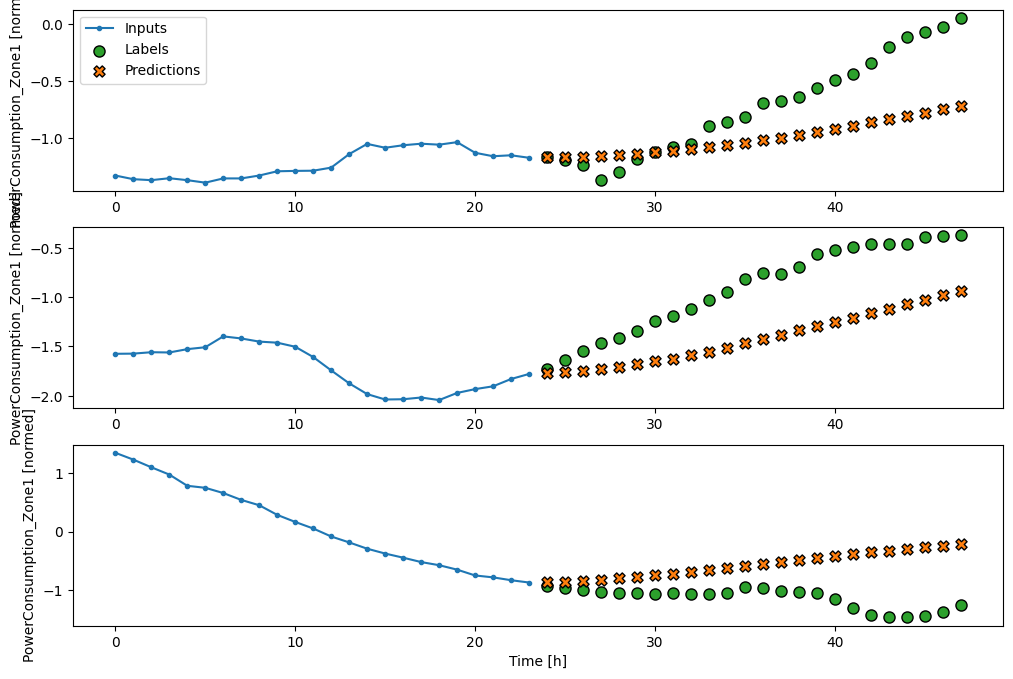

In [ ]:
multi_linear_model = tf.keras.Sequential([
    # Take the last time-step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_linear_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Linear'] = multi_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Linear'] = multi_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_linear_model)

More layers can give it more power(understanding) but it is stil limited by a single input to then predict multiple

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3006 - mean_absolute_error: 0.3636


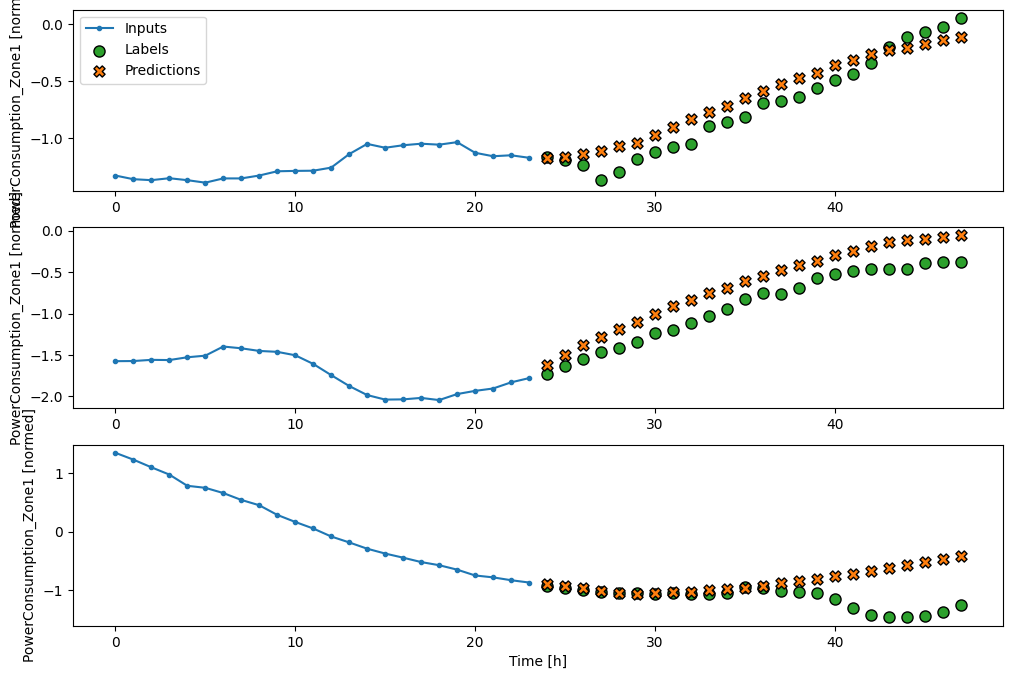

In [ ]:
multi_dense_model = tf.keras.Sequential([
    # Take the last time step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, dense_units]
    tf.keras.layers.Dense(512, activation='relu'),
    # Shape => [batch, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_dense_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Dense'] = multi_dense_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Dense'] = multi_dense_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_dense_model)

CNN

Wide window gives more context to patterns and change

327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2940 - mean_absolute_error: 0.3499


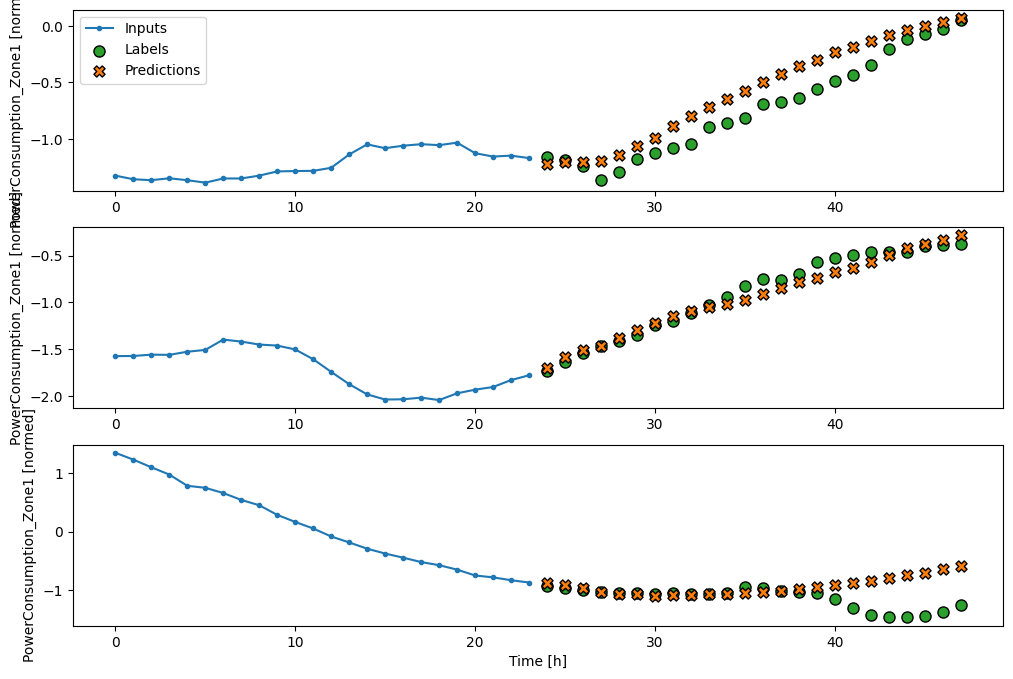

In [ ]:
CONV_WIDTH = 3
multi_conv_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, CONV_WIDTH, features]
    tf.keras.layers.Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    # Shape => [batch, 1, conv_units]
    tf.keras.layers.Conv1D(256, activation='relu', kernel_size=(CONV_WIDTH)),
    # Shape => [batch, 1,  out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_conv_model, multi_window)

IPython.display.clear_output()

multi_val_performance['Conv'] = multi_conv_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Conv'] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_conv_model)

RNN

Can take a long history of inputs and find whats relevant before making the next 24 hours prediction

327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2497 - mean_absolute_error: 0.3207


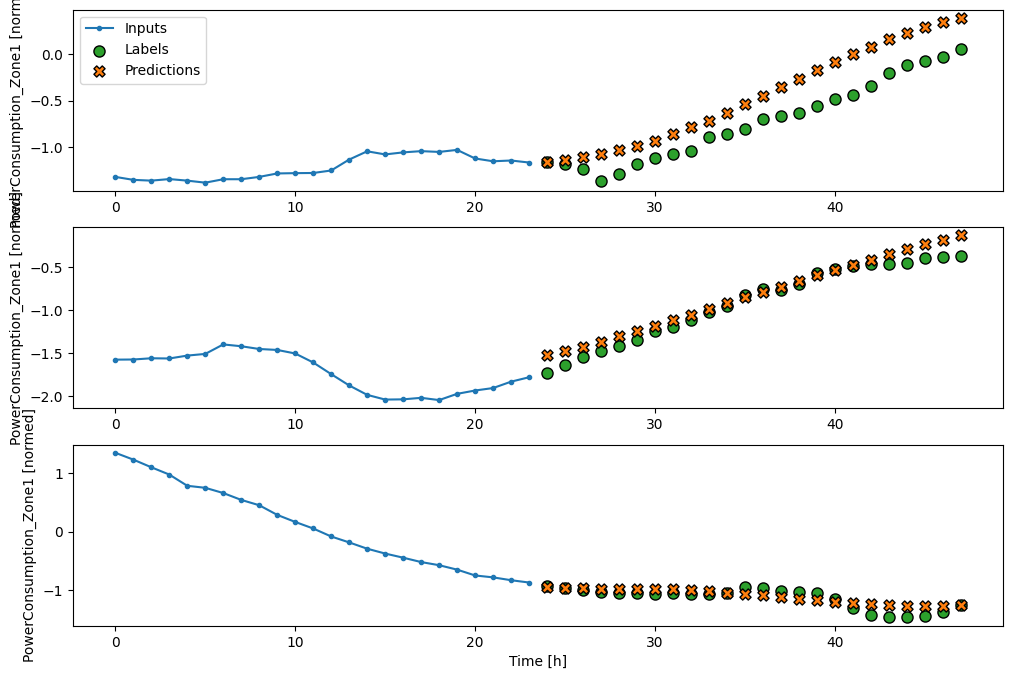

In [ ]:
multi_lstm_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, lstm_units].
    # Adding more `lstm_units` just overfits more quickly.
    tf.keras.layers.LSTM(32, return_sequences=False),
    # Shape => [batch, out_steps*features].
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features].
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_lstm_model, multi_window)

IPython.display.clear_output()

multi_val_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.val, return_dict=True)
multi_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_lstm_model)

Autoregressive models

This model makes predictions step by step but there is interaction from previous inputs that are ingested to get the next output. You can have a varying length of returned outputs and many of the single shot models can be turned to autoregressive

In the tutorial this will be done with a RNN model with manual managment

In [ ]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units)
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    self.dense = tf.keras.layers.Dense(num_features)

In [ ]:
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS)

Setting the warmup for the RNN's internal state through history

In [ ]:
def warmup(self, inputs):
  # inputs.shape => (batch, time, features)
  # x.shape => (batch, lstm_units)
  x, *state = self.lstm_rnn(inputs)

  # predictions.shape => (batch, features)
  prediction = self.dense(x)
  return prediction, state

FeedBack.warmup = warmup


Show internal state and make the first prediction

In [ ]:
prediction, state = feedback_model.warmup(multi_window.example[0])
print(prediction.shape)



(32, 8)


now iterating the model input feeding and storing outputs into a python list

In [ ]:
def call(self, inputs, training=None):
  # Use a TensorArray to capture dynamically unrolled outputs.
  predictions = []
  # Initialize the LSTM state.
  prediction, state = self.warmup(inputs)

  # Insert the first prediction.
  predictions.append(prediction)

  # Run the rest of the prediction steps.
  for n in range(1, self.out_steps):
    # Use the last prediction as input.
    x = prediction
    # Execute one lstm step.
    x, state = self.lstm_cell(x, states=state,
                              training=training)
    # Convert the lstm output to a prediction.
    prediction = self.dense(x)
    # Add the prediction to the output.
    predictions.append(prediction)

  # predictions.shape => (time, batch, features)
  predictions = tf.stack(predictions)
  # predictions.shape => (batch, time, features)
  predictions = tf.transpose(predictions, [1, 0, 2])
  return predictions

FeedBack.call = call

In [ ]:
print('Output shape (batch, time, features): ', feedback_model(multi_window.example[0]).shape)

Output shape (batch, time, features):  (32, 24, 8)


Train and plot

327/327 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.3067 - mean_absolute_error: 0.3906


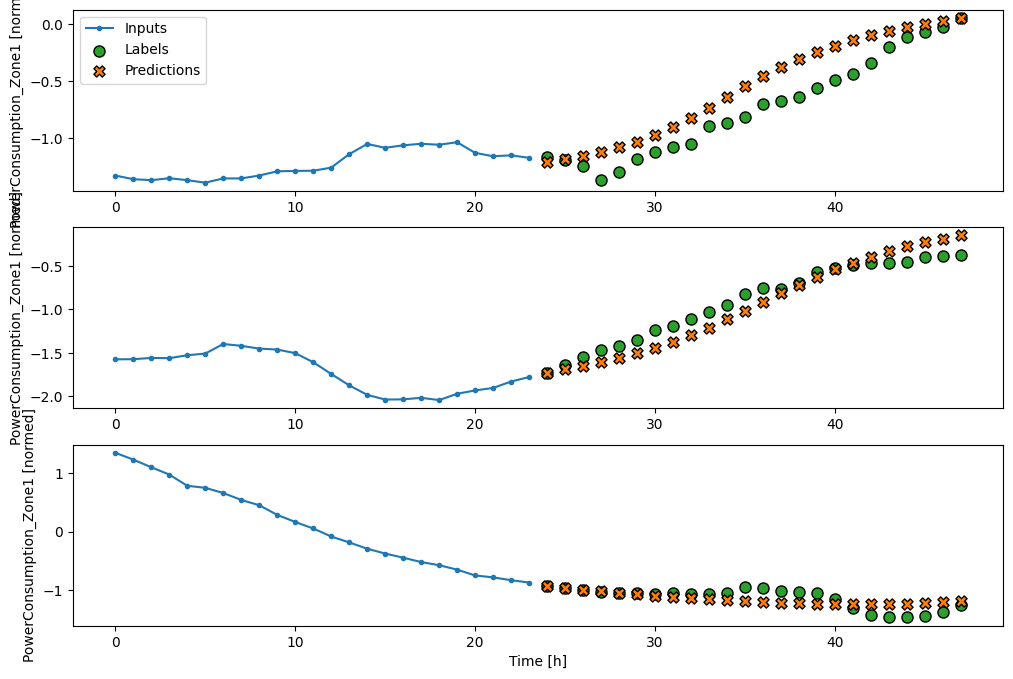

In [ ]:
history = compile_and_fit(feedback_model, multi_window)

IPython.display.clear_output()

multi_val_performance['AR LSTM'] = feedback_model.evaluate(multi_window.val, return_dict=True)
multi_performance['AR LSTM'] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)

Now I'm going to try a dense autoregressive linear model. I wanted to see if knowing it's previous prediction would make the AR better than without.

In [ ]:
class FeedBackDenseLinear(tf.keras.Model):
    def __init__(self, units, out_steps):
        super().__init__()

        self.out_steps = out_steps

        self.dense_model = tf.keras.Sequential([
            tf.keras.layers.Dense(units, activation='relu'),
            tf.keras.layers.Dense(num_features)
        ])

    def warmup(self, inputs):

        # Take last timestep
        x = inputs[:, -1, :]

        prediction = self.dense_model(x)

        return prediction

    def call(self, inputs, training=None):

        predictions = []

        prediction = self.warmup(inputs)

        predictions.append(prediction)

        for n in range(1, self.out_steps):

            x = prediction

            prediction = self.dense_model(x)

            predictions.append(prediction)

        predictions = tf.stack(predictions)

        predictions = tf.transpose(predictions, [1, 0, 2])

        return predictions

train and fit

327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5169 - mean_absolute_error: 0.5615


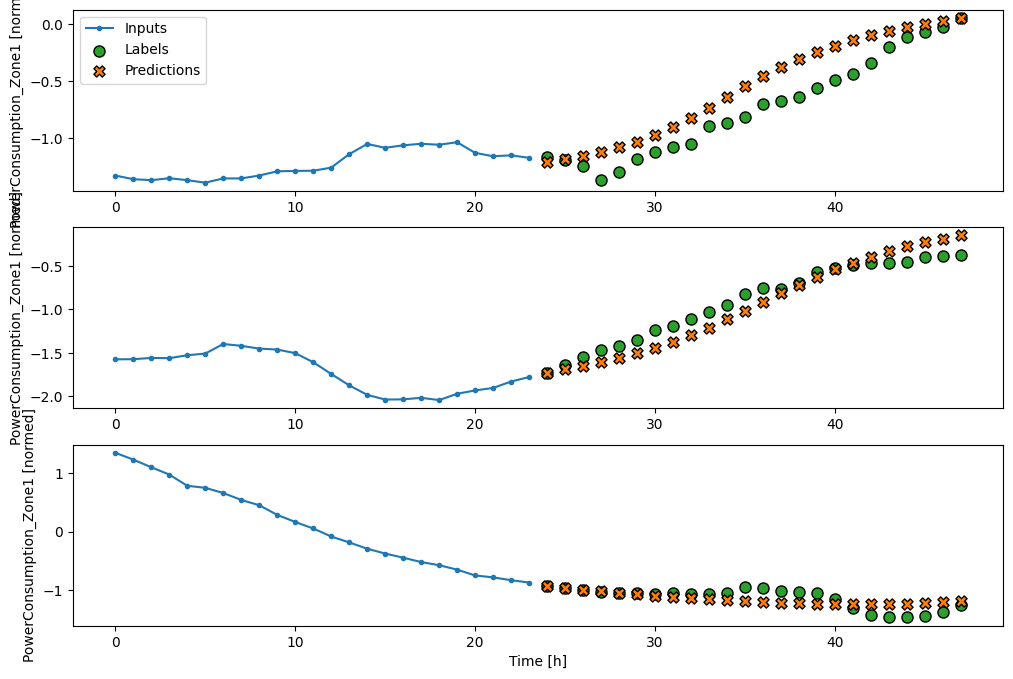

In [ ]:
feedback_linear_model = FeedBackDenseLinear(units=32, out_steps=OUT_STEPS)
history = compile_and_fit(feedback_linear_model, multi_window)

IPython.display.clear_output()

multi_val_performance['AR Linear'] = feedback_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance['AR Linear'] = feedback_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)

Show performance on each model

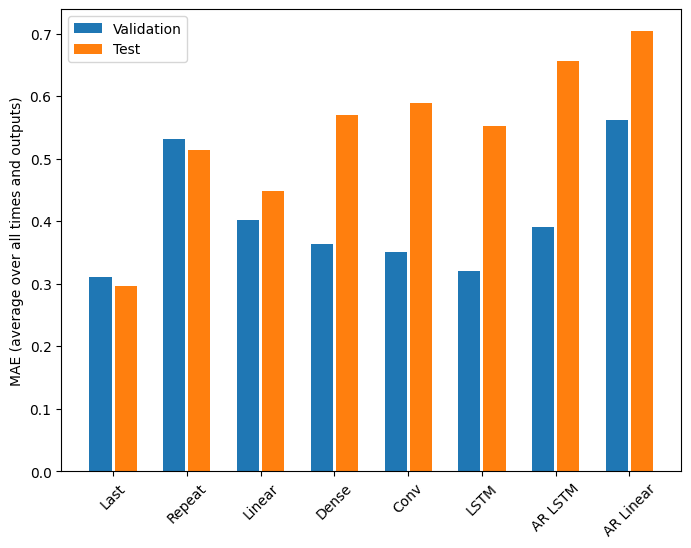

In [ ]:
x = np.arange(len(multi_performance))
width = 0.3

metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=multi_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

Average for each model through time steps

In [ ]:
for name, value in multi_performance.items():
  print(f'{name:9s}: {value[metric_name]:0.4f}')

Last     : 0.2959
Repeat   : 0.5140
Linear   : 0.4488
Dense    : 0.5691
Conv     : 0.5893
LSTM     : 0.5523
AR LSTM  : 0.6558
AR Linear: 0.7039


With this new dataset the metrics for error is better and prediction power are worse than on the original dataset. This could be due to the small amount of powerful features the models have to decide with only its zone being made relevant in one of the models. It is interesting how much worse AR linear is to regular linear. Also interesting how the general models did better than the one shot and AR models.

This project and data has a lot of I've never seen before which I want to continue pursing and learning from.
